# 03 · Off-Policy Evaluation

Offline ranking metrics rank *models*. They do not tell us the **online value**
of deploying a new recommender — for that you normally need a live A/B test,
which is slow and risky. **Off-policy evaluation (OPE)** estimates that online
value from logs already collected under the *current* system.

This is the counterfactual question — "what *would* happen if we switched
policies?" — the same causal logic as the sibling uplift project, applied to
recommendation.

**Setup (a controlled simulation, so we know the ground truth):**
- context = user, actions = the 200 most-popular items, reward = the user
  genuinely likes the item (from full data).
- **logging policy** π₀ — an exploratory popularity policy (the "current
  system").
- **target policy** π₁ — a sharp iALS policy (the recommender we might ship).

We log one interaction per user under π₀, then estimate V(π₁) with four
estimators and check each against the true V(π₁).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

In [2]:
from sklearn.linear_model import LogisticRegression
from src.data.load import load_ratings, temporal_split
from src.recommenders.ials import IALS
from src.ope.estimators import (softmax_policy, simulate_bandit_logs, true_policy_value,
                                 ips, snips, direct_method, doubly_robust, effective_sample_size)

df = load_ratings(); sp = temporal_split(df, 0.2, 10)
train = sp.train_matrix(); ials = IALS().fit(train)
pop = np.asarray(train.sum(axis=0)).ravel()
users = np.arange(sp.n_users)

N_CAND = 200
cand = np.argsort(-pop)[:N_CAND]                       # candidate action set
liked = set(map(tuple, df[df.liked == 1][["user_idx", "item_idx"]].values))
R = np.array([[1.0 if (u, i) in liked else 0.0 for i in cand] for u in users])   # true reward
print("reward matrix:", R.shape, "| mean reward:", R.mean().round(3))

reward matrix: (6040, 200) | mean reward: 0.18


## Define the two policies and their ground-truth values

In [3]:
ials_scores = ials.score_users(users)[:, cand]
pop_scores = np.tile(pop[cand], (len(users), 1))

pi0 = softmax_policy(pop_scores, temperature=pop[cand].std() * 3, epsilon=0.5)   # logging (exploratory)
pi1 = softmax_policy(ials_scores, temperature=0.3, epsilon=0.05)                 # target (sharp iALS)

V0 = true_policy_value(pi0, R)
V1 = true_policy_value(pi1, R)
print(f"TRUE value of logging policy pi0 : {V0:.4f}")
print(f"TRUE value of target  policy pi1 : {V1:.4f}")
print(f"the target policy would lift reward by {(V1 - V0) / V0:+.0%}")

TRUE value of logging policy pi0 : 0.1960
TRUE value of target  policy pi1 : 0.4135
the target policy would lift reward by +111%


## Estimate V(π₁) from logs — four estimators

We repeat the log simulation over many seeds to measure each estimator's **bias
and variance**. The reward model behind DM/DR is a logistic regression on
`[iALS score, log popularity]`, fit only on the logged data.

In [4]:
def q_matrix(rm, u):
    # vectorised reward-model prediction for every (logged user, candidate action)
    n = len(u)
    feats = np.column_stack([
        ials_scores[u].ravel(),
        np.log1p(np.tile(pop[cand], n)),
    ])
    return rm.predict_proba(feats)[:, 1].reshape(n, N_CAND)

results = {"IPS": [], "SNIPS": [], "DM": [], "DR": []}
ess_vals = []
for seed in range(20):
    log = simulate_bandit_logs(pi0, R, seed=seed)
    u, a, r, ps = log["context"], log["action"], log["reward"], log["pscore"]
    tps = pi1[u, a]
    rm = LogisticRegression(max_iter=500).fit(
        np.column_stack([ials_scores[u, a], np.log1p(pop[cand][a])]), r)
    q_all = q_matrix(rm, u)
    q_logged = q_all[np.arange(len(u)), a]
    v_target = np.sum(pi1[u] * q_all, axis=1)
    results["IPS"].append(ips(r, ps, tps))
    results["SNIPS"].append(snips(r, ps, tps))
    results["DM"].append(direct_method(v_target))
    results["DR"].append(doubly_robust(r, ps, tps, q_logged, v_target))
    ess_vals.append(effective_sample_size(ps, tps))

summary = pd.DataFrame({
    name: {"estimate": np.mean(v), "bias": np.mean(v) - V1,
           "std": np.std(v), "rmse": np.sqrt(np.mean((np.array(v) - V1) ** 2))}
    for name, v in results.items()
}).T
print(f"true V(pi1) = {V1:.4f} | mean ESS = {np.mean(ess_vals):.0f} / {len(u)} logged")
summary

true V(pi1) = 0.4135 | mean ESS = 2557 / 6040 logged


,estimate,bias,std,rmse
IPS,0.415717,0.002261,0.012164,0.012372
SNIPS,0.417362,0.003906,0.009812,0.010561
DM,0.420369,0.006913,0.007712,0.010357
DR,0.417872,0.004416,0.008955,0.009984


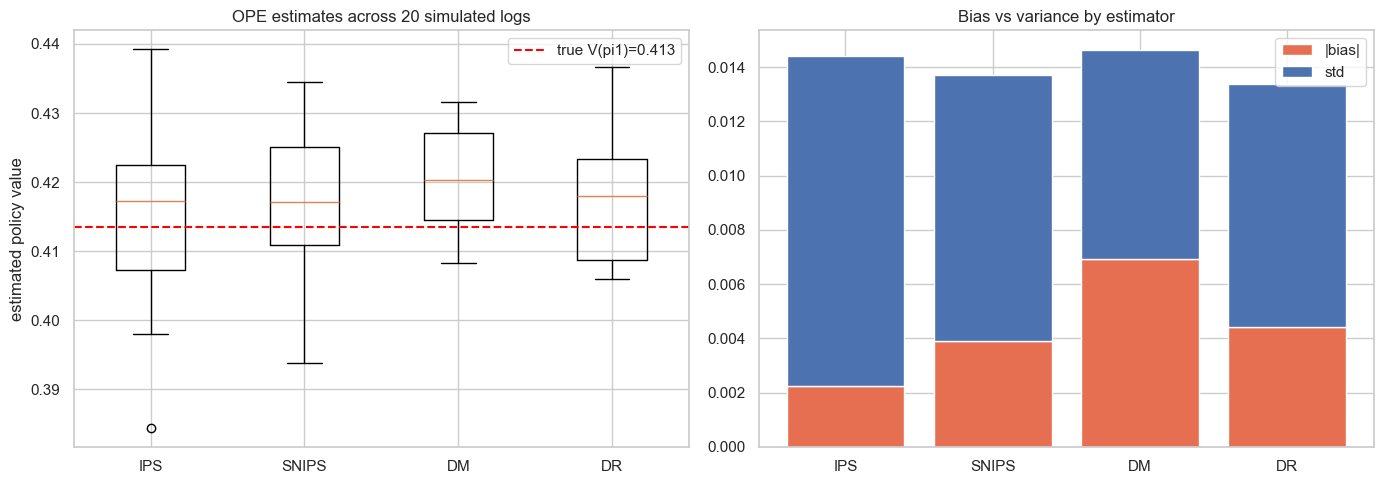

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# left: estimate distributions vs truth
axes[0].boxplot([results[k] for k in results], labels=list(results))
axes[0].axhline(V1, color="red", ls="--", label=f"true V(pi1)={V1:.3f}")
axes[0].set_title("OPE estimates across 20 simulated logs"); axes[0].set_ylabel("estimated policy value"); axes[0].legend()
# right: bias-variance decomposition of RMSE
axes[1].bar(summary.index, summary["bias"].abs(), label="|bias|", color="#e76f51")
axes[1].bar(summary.index, summary["std"], bottom=summary["bias"].abs(), label="std", color="#4c72b0")
axes[1].set_title("Bias vs variance by estimator"); axes[1].legend()
plt.tight_layout(); plt.savefig(FIG / "03_ope_estimators.png", dpi=120, bbox_inches="tight"); plt.show()

## Takeaways

- **All four estimators correctly conclude the target policy is far better**
  than the logging policy — using only logged data, no A/B test.
- The classic bias/variance pattern comes through cleanly:
  - **IPS** is (near-)unbiased but has the highest variance.
  - **DM** has the lowest variance but the largest bias (it inherits the reward
    model's error).
  - **SNIPS** and especially **DR** give the best RMSE — DR is unbiased if
    *either* the propensities or the reward model are correct, so it hedges.
- The **effective sample size** (~2.5k of 6k logged) is the diagnostic that
  tells us how far we can trust IPS: had π₀ and π₁ barely overlapped, ESS would
  collapse and IPS would be worthless. Notebook 04 uses DR to choose which
  recommender to ship.